<a href="https://colab.research.google.com/github/ACRivera1/data-quality-engine/blob/main/Healthcare_Patient_Survey_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Healthcare Patient Survey — Full Analysis
### Schema Design + Dimension/Fact Tables + 8 Sample Reports

---

**Dataset:** `Health_Care_Patient_survey_source.csv` — 35,000 rows of US hospital patient survey data

**Goal:** Build a Star/Snowflake schema, load dimensional tables, and answer 8 business questions with charts.

---

## 📋 Table of Contents
- [Section 1: Install & Import Libraries](#section-1)
- [Section 2: Load & Inspect Raw Data](#section-2)
- [Section 3: Data Cleaning](#section-3)
- [Section 4: Build Dimension Tables](#section-4)
- [Section 5: Build Fact Table](#section-5)
- [Section 6: Report 1 — Surveys Completed by Hospital](#section-6)
- [Section 7: Report 2 — Response Rate by Measure ID](#section-7)
- [Section 8: Report 3 — Top 3 Counties by Survey Rate](#section-8)
- [Section 9: Report 4 — Top 10 Hospitals by Star Rating](#section-9)
- [Section 10: Report 5 — County & City Drill-Down Rating](#section-10)
- [Section 11: Report 6 — Hospitals in the Same City](#section-11)
- [Section 12: Report 7 — Total Response Rate by Hospital](#section-12)
- [Section 13: Report 8 — New Insight Report](#section-13)


---
<a id='section-1'></a>
## Section 1: Install & Import Libraries

Every data science project starts here. We install the tools we need, then import them.

| Library | What it does |
|---|---|
| `pandas` | Loads, cleans, and reshapes tabular data |
| `numpy` | Fast math on arrays |
| `matplotlib` | Core plotting engine |
| `seaborn` | Beautiful statistical charts |
| `plotly` | Interactive charts (hover, zoom, drill-down) |


In [7]:
# ── Install all required libraries ───────────────────────────────────────────
# The ! prefix runs this as a terminal command (not Python).
# Run this cell once. It's safe to re-run — pip skips already-installed packages.
!pip install pandas numpy matplotlib seaborn plotly


In [8]:
# ── Import libraries ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')          # keep output clean

import pandas as pd                        # DataFrames — our main data structure
import numpy as np                         # numerical operations

import matplotlib.pyplot as plt            # base plotting
import matplotlib.ticker as mticker        # axis formatting helpers
import seaborn as sns                      # statistical charts

import plotly.express as px                # interactive charts
import plotly.graph_objects as go          # low-level plotly objects
from plotly.subplots import make_subplots  # multiple plotly panels

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)           # show all columns
pd.set_option('display.max_rows', 20)              # limit rows shown
pd.set_option('display.float_format', '{:,.2f}'.format)  # comma formatting
sns.set_theme(style='whitegrid', palette='muted')  # clean seaborn style
%matplotlib inline

print('✅ All libraries imported!')


✅ All libraries imported!


---
<a id='section-2'></a>
## Section 2: Load & Inspect the Raw Data

Before writing a single line of analysis, we always **look at the data** first.
This prevents surprises later and shapes every decision we make.


In [9]:
# ── Load the CSV file ────────────────────────────────────────────────────────
# pd.read_csv() reads a file from disk into a DataFrame.
# encoding='latin-1' handles special characters that 'utf-8' would crash on.
# Place the CSV in the SAME FOLDER as this notebook.

raw = pd.read_csv('Health Care_Patient_survey_source.csv', encoding='latin-1')

print(f'Rows    : {raw.shape[0]:,}')
print(f'Columns : {raw.shape[1]}')


Rows    : 34,999
Columns : 23


In [10]:
# ── Preview the first 5 rows ─────────────────────────────────────────────────
# display() renders a formatted HTML table in Jupyter (prettier than print)
display(raw.head())


,Provider ID,Hospital Name,Address,City,State,ZIP Code,County Name,Phone Number,Measure ID,Question,Answer Description,Patient Survey Star Rating,Patient Survey Star Rating Footnote,Answer Percent,Answer Percent Footnote,Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Measure Start Date,Measure End Date,Location
0,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,"Room was ""always"" clean",Not Applicable,NaN,63,NaN,Not Applicable,506,NaN,21,NaN,07/01/17,06/30/2018,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
1,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",Not Applicable,NaN,13,NaN,Not Applicable,506,NaN,21,NaN,07/01/17,06/30/2018,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
2,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,"Room was ""usually"" clean",Not Applicable,NaN,24,NaN,Not Applicable,506,NaN,21,NaN,07/01/17,06/30/2018,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
3,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_LINEAR_SCORE,Cleanliness - linear mean score,Cleanliness - linear mean score,Not Applicable,NaN,Not Applicable,NaN,83,506,NaN,21,NaN,07/01/17,06/30/2018,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
4,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,3347938701,H_CLEAN_STAR_RATING,Cleanliness - star rating,Cleanliness - star rating,2,NaN,Not Applicable,NaN,Not Applicable,506,NaN,21,NaN,07/01/17,06/30/2018,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."


In [11]:
# ── Column names, data types, and non-null counts ────────────────────────────
# .info() is the fastest way to understand the structure of a DataFrame.
# 'object' dtype = text/string; int64/float64 = numbers.
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34999 entries, 0 to 34998
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Provider ID                            34999 non-null  int64 
 1   Hospital Name                          34999 non-null  object
 2   Address                                34999 non-null  object
 3   City                                   34999 non-null  object
 4   State                                  34999 non-null  object
 5   ZIP Code                               34999 non-null  int64 
 6   County Name                            34749 non-null  object
 7   Phone Number                           34999 non-null  int64 
 8   Measure ID                             34999 non-null  object
 9   Question                               34999 non-null  object
 10  Answer Description                     34999 non-null  object
 11  Patient Survey 

In [12]:
# ── Count missing values per column ──────────────────────────────────────────
# .isnull() returns True where a cell is empty.
# .sum() counts the Trues. Multiplying by 100/len gives the % missing.

missing = pd.DataFrame({
    'Missing Count': raw.isnull().sum(),
    'Missing %'    : (raw.isnull().sum() / len(raw) * 100).round(1)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('Columns with missing values:')
display(missing)


Columns with missing values:


,Missing Count,Missing %
Patient Survey Star Rating Footnote,33261,95.00
Answer Percent Footnote,29837,85.30
Number of Completed Surveys Footnote,26099,74.60
Survey Response Rate Percent Footnote,26099,74.60
County Name,250,0.70


In [13]:
# ── Unique value counts for key columns ──────────────────────────────────────
# .nunique() counts how many distinct values exist in each column.
# This tells us the cardinality — useful for dimension table sizing.

key_cols = ['Hospital Name','City','State','County Name','Measure ID','ZIP Code']
for col in key_cols:
    print(f'{col:35s}: {raw[col].nunique():>5} unique values')


Hospital Name                      :   695 unique values
City                               :   500 unique values
State                              :     7 unique values
County Name                        :   231 unique values
Measure ID                         :    50 unique values
ZIP Code                           :   629 unique values


In [14]:
# ── Look at what Measure IDs exist ───────────────────────────────────────────
# Measure ID is the survey category (e.g. cleanliness, communication, etc.)
print('All unique Measure IDs:')
for mid in sorted(raw['Measure ID'].unique()):
    print(f'  {mid}')


All unique Measure IDs:
  H_CLEAN_HSP_A_P
  H_CLEAN_HSP_SN_P
  H_CLEAN_HSP_U_P
  H_CLEAN_LINEAR_SCORE
  H_CLEAN_STAR_RATING
  H_COMP_1_A_P
  H_COMP_1_LINEAR_SCORE
  H_COMP_1_SN_P
  H_COMP_1_STAR_RATING
  H_COMP_1_U_P
  H_COMP_2_A_P
  H_COMP_2_LINEAR_SCORE
  H_COMP_2_SN_P
  H_COMP_2_STAR_RATING
  H_COMP_2_U_P
  H_COMP_3_A_P
  H_COMP_3_LINEAR_SCORE
  H_COMP_3_SN_P
  H_COMP_3_STAR_RATING
  H_COMP_3_U_P
  H_COMP_5_A_P
  H_COMP_5_LINEAR_SCORE
  H_COMP_5_SN_P
  H_COMP_5_STAR_RATING
  H_COMP_5_U_P
  H_COMP_6_LINEAR_SCORE
  H_COMP_6_N_P
  H_COMP_6_STAR_RATING
  H_COMP_6_Y_P
  H_COMP_7_A
  H_COMP_7_D_SD
  H_COMP_7_LINEAR_SCORE
  H_COMP_7_SA
  H_COMP_7_STAR_RATING
  H_HSP_RATING_0_6
  H_HSP_RATING_7_8
  H_HSP_RATING_9_10
  H_HSP_RATING_LINEAR_SCORE
  H_HSP_RATING_STAR_RATING
  H_QUIET_HSP_A_P
  H_QUIET_HSP_SN_P
  H_QUIET_HSP_U_P
  H_QUIET_LINEAR_SCORE
  H_QUIET_STAR_RATING
  H_RECMND_DN
  H_RECMND_DY
  H_RECMND_LINEAR_SCORE
  H_RECMND_PY
  H_RECMND_STAR_RATING
  H_STAR_RATING


In [15]:
# ── Sample values for numeric-looking columns (stored as text) ───────────────
# Several columns are stored as strings because they contain values like
# 'Not Applicable' or 'Not Available'. We'll convert them to numbers in Section 3.

text_numeric = ['Number of Completed Surveys', 'Survey Response Rate Percent',
                'Answer Percent', 'Linear Mean Value', 'Patient Survey Star Rating']

for col in text_numeric:
    unique_vals = raw[col].unique()[:6]   # show first 6 unique values
    print(f'{col}:\n  Sample: {list(unique_vals)}\n')


Number of Completed Surveys:
  Sample: ['506', '1135', '579', '185', '63', '2193']

Survey Response Rate Percent:
  Sample: ['21', '34', '22', '27', '31', '33']

Answer Percent:
  Sample: ['63', '13', '24', 'Not Applicable', '70', '9']

Linear Mean Value:
  Sample: ['Not Applicable', '83', '87', '90', '75', '70']

Patient Survey Star Rating:
  Sample: ['Not Applicable', '2', '3', '1', '4', 'Not Available']



---
<a id='section-3'></a>
## Section 3: Data Cleaning

Raw data is almost never ready to use. We need to:
1. Fix column names (remove spaces)
2. Convert text numbers to real numbers
3. Parse dates
4. Handle missing values
5. Strip whitespace from text fields


In [16]:
# ── Step 3.1: Work on a copy so the original raw data is never modified ───────
# Best practice: always keep 'raw' untouched as a backup reference.
df = raw.copy()

# ── Step 3.2: Rename columns — replace spaces with underscores ────────────────
# Python column names with spaces require df['col name'] syntax everywhere.
# Underscored names allow df.col_name — cleaner and less error-prone.
df.columns = (
    df.columns
    .str.strip()              # remove leading/trailing whitespace
    .str.replace(' ', '_')   # replace spaces with underscores
    .str.replace('/', '_')   # slashes can cause issues in some tools
)

print('Renamed columns:')
print(df.columns.tolist())


Renamed columns:
['Provider_ID', 'Hospital_Name', 'Address', 'City', 'State', 'ZIP_Code', 'County_Name', 'Phone_Number', 'Measure_ID', 'Question', 'Answer_Description', 'Patient_Survey_Star_Rating', 'Patient_Survey_Star_Rating_Footnote', 'Answer_Percent', 'Answer_Percent_Footnote', 'Linear_Mean_Value', 'Number_of_Completed_Surveys', 'Number_of_Completed_Surveys_Footnote', 'Survey_Response_Rate_Percent', 'Survey_Response_Rate_Percent_Footnote', 'Measure_Start_Date', 'Measure_End_Date', 'Location']


In [17]:
# ── Step 3.3: Strip whitespace from all text columns ─────────────────────────
# Text data often has invisible leading/trailing spaces.
# 'HOUSTON' and 'HOUSTON ' look the same but are NOT equal — causing bad groupbys.

# Select only object (string) columns
str_cols = df.select_dtypes(include='object').columns

# Apply .str.strip() to remove whitespace from every string column
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print(f'Stripped whitespace from {len(str_cols)} text columns.')


Stripped whitespace from 20 text columns.


In [18]:
# ── Step 3.4: Convert numeric columns stored as text ─────────────────────────
# pd.to_numeric(..., errors='coerce') tries to convert each value to a number.
# Values like 'Not Applicable' or 'Not Available' CANNOT be converted,
# so errors='coerce' turns them into NaN (missing) instead of crashing.

numeric_cols = [
    'Number_of_Completed_Surveys',
    'Survey_Response_Rate_Percent',
    'Answer_Percent',
    'Linear_Mean_Value',
    'Patient_Survey_Star_Rating',
]

for col in numeric_cols:
    before = df[col].dtype                          # dtype before conversion
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert; non-numbers → NaN
    valid  = df[col].notna().sum()                  # count successfully converted
    print(f'{col}: {before} → {df[col].dtype} | valid={valid:,} | NaN={df[col].isna().sum():,}')


Number_of_Completed_Surveys: object → float64 | valid=30,949 | NaN=4,050
Survey_Response_Rate_Percent: object → float64 | valid=30,949 | NaN=4,050
Answer_Percent: object → float64 | valid=17,951 | NaN=17,048
Linear_Mean_Value: object → float64 | valid=5,420 | NaN=29,579
Patient_Survey_Star_Rating: object → float64 | valid=5,961 | NaN=29,038


In [19]:
# ── Step 3.5: Parse date columns ─────────────────────────────────────────────
# Dates are stored as strings like '07/01/17'. pd.to_datetime() converts them
# to proper datetime objects so we can do date arithmetic.

df['Measure_Start_Date'] = pd.to_datetime(df['Measure_Start_Date'], errors='coerce')
df['Measure_End_Date']   = pd.to_datetime(df['Measure_End_Date'],   errors='coerce')

print('Date range of survey data:')
print(f'  Start: {df["Measure_Start_Date"].min()}')
print(f'  End  : {df["Measure_End_Date"].max()}')


Date range of survey data:
  Start: 2017-07-01 00:00:00
  End  : 2018-06-30 00:00:00


In [20]:
# ── Step 3.6: Fill missing County Names ──────────────────────────────────────
# 250 rows have no County Name. We fill them with 'Unknown' so they don't
# disappear from groupby operations.

df['County_Name'] = df['County_Name'].fillna('Unknown')
print(f'Missing County_Name after fill: {df["County_Name"].isnull().sum()}')


Missing County_Name after fill: 0


In [21]:
# ── Step 3.7: Standardise text casing ────────────────────────────────────────
# Hospital names and city names should be consistently capitalised.
# .str.title() converts 'SOUTHEAST ALABAMA MEDICAL CENTER' → 'Southeast Alabama Medical Center'

df['Hospital_Name'] = df['Hospital_Name'].str.title()
df['City']          = df['City'].str.title()
df['County_Name']   = df['County_Name'].str.title()

print('Sample hospital names after title-casing:')
print(df['Hospital_Name'].unique()[:5])


Sample hospital names after title-casing:
['Southeast Alabama Medical Center' 'Marshall Medical Center South'
 'Eliza Coffee Memorial Hospital' 'Mizell Memorial Hospital'
 'Crenshaw Community Hospital']


In [22]:
# ── Step 3.8: Final cleaned dataset summary ───────────────────────────────────
print(f'Final cleaned shape: {df.shape}')
print()
display(df.head(3))


Final cleaned shape: (34999, 23)



,Provider_ID,Hospital_Name,Address,City,State,ZIP_Code,County_Name,Phone_Number,Measure_ID,Question,Answer_Description,Patient_Survey_Star_Rating,Patient_Survey_Star_Rating_Footnote,Answer_Percent,Answer_Percent_Footnote,Linear_Mean_Value,Number_of_Completed_Surveys,Number_of_Completed_Surveys_Footnote,Survey_Response_Rate_Percent,Survey_Response_Rate_Percent_Footnote,Measure_Start_Date,Measure_End_Date,Location
0,10001,Southeast Alabama Medical Center,1108 ROSS CLARK CIRCLE,Dothan,AL,36301,Houston,3347938701,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,"Room was ""always"" clean",NaN,NaN,63.00,NaN,NaN,506.00,NaN,21.00,NaN,2017-07-01,2018-06-30,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
1,10001,Southeast Alabama Medical Center,1108 ROSS CLARK CIRCLE,Dothan,AL,36301,Houston,3347938701,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",NaN,NaN,13.00,NaN,NaN,506.00,NaN,21.00,NaN,2017-07-01,2018-06-30,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
2,10001,Southeast Alabama Medical Center,1108 ROSS CLARK CIRCLE,Dothan,AL,36301,Houston,3347938701,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,"Room was ""usually"" clean",NaN,NaN,24.00,NaN,NaN,506.00,NaN,21.00,NaN,2017-07-01,2018-06-30,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."


---
<a id='section-4'></a>
## Section 4: Build Dimension Tables

A **Snowflake Schema** separates data into:
- **Dimension tables** — descriptive attributes (WHO, WHAT, WHERE)
- **Fact table** — measurable events/numbers (HOW MANY, HOW MUCH)

We build 4 dimension tables from the cleaned flat file:

```
Dim_Country_Details  ←── Fact_Patient_Survey ──→ Dim_Hospital_Details
Dim_Measure_Details  ←──         │            ──→ Dim_Survey_Details
```

Each dimension gets a **surrogate primary key** — a simple auto-incrementing integer
we create ourselves. This is better than using raw values (names can change; numbers don't).


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# DIM_COUNTRY_DETAILS
# Fields: Country_Id (PK), Country_Name, State, City, ZipCode
# ════════════════════════════════════════════════════════════════════════════

# Step 1: Extract the unique combination of State + City + ZipCode.
# In this dataset all hospitals are in the USA, so Country_Name = 'USA' for all.
# .drop_duplicates() keeps only unique rows — removes all duplicate combinations.

dim_country = (
    df[['State', 'City', 'ZIP_Code']]     # select only the columns we need
    .drop_duplicates()                      # one row per unique State+City+Zip combo
    .reset_index(drop=True)                # reset row numbers to 0,1,2,...
)

# Step 2: Add the Country_Name column (constant value for all rows)
dim_country.insert(0, 'Country_Name', 'USA')   # insert() puts it at position 0 (first column)

# Step 3: Generate the surrogate primary key — Country_Id
# range(1, n+1) creates 1,2,3,...,n  (we start at 1, not 0, following DB convention)
dim_country.insert(0, 'Country_Id', range(1, len(dim_country) + 1))

# Step 4: Rename columns to match the schema specification
dim_country = dim_country.rename(columns={'ZIP_Code': 'ZipCode'})

print(f'Dim_Country_Details: {dim_country.shape[0]:,} rows × {dim_country.shape[1]} columns')
display(dim_country.head(8))


Dim_Country_Details: 629 rows × 5 columns


,Country_Id,Country_Name,State,City,ZipCode
0,1,USA,AL,Dothan,36301
1,2,USA,AL,Boaz,35957
2,3,USA,AL,Florence,35631
3,4,USA,AL,Opp,36467
4,5,USA,AL,Luverne,36049
5,6,USA,AL,Birmingham,35235
6,7,USA,AL,Fort Payne,35968
7,8,USA,AL,Alabaster,35007


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# DIM_HOSPITAL_DETAILS
# Fields: Hospital_Id (PK), Country_Id (FK), Hospital_Name, City, Location
# ════════════════════════════════════════════════════════════════════════════

# Step 1: Extract unique hospitals
# Provider_ID from the source is the hospital's real-world ID.
# We still create our own surrogate Hospital_Id for the schema.

dim_hospital = (
    df[['Provider_ID', 'Hospital_Name', 'City', 'State', 'ZIP_Code', 'Location']]
    .drop_duplicates(subset=['Provider_ID'])   # one row per unique hospital
    .reset_index(drop=True)
)

# Step 2: Join with Dim_Country to get Country_Id (the Foreign Key)
# We match on City + State + ZIP_Code — the combination that links the two tables.
# how='left' keeps all hospitals even if there's no matching country row.
dim_hospital = dim_hospital.merge(
    dim_country[['Country_Id', 'State', 'City', 'ZipCode']],
    left_on  = ['State', 'City', 'ZIP_Code'],
    right_on = ['State', 'City', 'ZipCode'],
    how='left'
)

# Step 3: Generate surrogate Hospital_Id
dim_hospital.insert(0, 'Hospital_Id', range(1, len(dim_hospital) + 1))

# Step 4: Keep only schema columns
dim_hospital = dim_hospital[['Hospital_Id','Country_Id','Hospital_Name','City','Location']]

print(f'Dim_Hospital_Details: {dim_hospital.shape[0]:,} rows × {dim_hospital.shape[1]} columns')
display(dim_hospital.head(5))


Dim_Hospital_Details: 700 rows × 5 columns


,Hospital_Id,Country_Id,Hospital_Name,City,Location
0,1,1,Southeast Alabama Medical Center,Dothan,"1108 ROSS CLARK CIRCLE DOTHAN, AL 36301 (31.21..."
1,2,2,Marshall Medical Center South,Boaz,"2505 U S HIGHWAY 431 NORTH BOAZ, AL 35957"
2,3,3,Eliza Coffee Memorial Hospital,Florence,"205 MARENGO STREET FLORENCE, AL 35631 (34.7936..."
3,4,4,Mizell Memorial Hospital,Opp,"702 N MAIN ST OPP, AL 36467 (31.291972, -86.25..."
4,5,5,Crenshaw Community Hospital,Luverne,"101 HOSPITAL CIRCLE LUVERNE, AL 36049 (31.6925..."


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# DIM_MEASURE_DETAILS
# Fields: Measure_id (PK), Measure_Id (natural key), Measure_Start_Date, Measure_End_Date
# ════════════════════════════════════════════════════════════════════════════

# Step 1: Get unique combinations of Measure ID + date range
# Note: The schema uses 'Measure_id' as PK (surrogate) and 'Measure_Id' as the
# natural business key (the string like 'H_CLEAN_HSP_A_P').

dim_measure = (
    df[['Measure_ID', 'Measure_Start_Date', 'Measure_End_Date']]
    .drop_duplicates(subset=['Measure_ID'])
    .reset_index(drop=True)
)

# Step 2: Generate surrogate primary key
dim_measure.insert(0, 'Measure_id', range(1, len(dim_measure) + 1))

# Step 3: Rename to match schema (natural key stays as Measure_Id)
dim_measure = dim_measure.rename(columns={
    'Measure_ID'        : 'Measure_Id',
    'Measure_Start_Date': 'Measure_Start_Date',
    'Measure_End_Date'  : 'Measure_End_Date',
})

print(f'Dim_Measure_Details: {dim_measure.shape[0]:,} rows × {dim_measure.shape[1]} columns')
display(dim_measure.head(8))


Dim_Measure_Details: 50 rows × 4 columns


,Measure_id,Measure_Id,Measure_Start_Date,Measure_End_Date
0,1,H_CLEAN_HSP_A_P,2017-07-01,2018-06-30
1,2,H_CLEAN_HSP_SN_P,2017-07-01,2018-06-30
2,3,H_CLEAN_HSP_U_P,2017-07-01,2018-06-30
3,4,H_CLEAN_LINEAR_SCORE,2017-07-01,2018-06-30
4,5,H_CLEAN_STAR_RATING,2017-07-01,2018-06-30
5,6,H_COMP_1_A_P,2017-07-01,2018-06-30
6,7,H_COMP_1_LINEAR_SCORE,2017-07-01,2018-06-30
7,8,H_COMP_1_SN_P,2017-07-01,2018-06-30


In [26]:
# ════════════════════════════════════════════════════════════════════════════
# DIM_SURVEY_DETAILS
# Fields: Survey_Id (PK), Survey_Question, Survey_Answer,
#         Patient_Survey_Star_Rating_FootNote
# ════════════════════════════════════════════════════════════════════════════

# Step 1: Extract unique survey question + answer combinations.
# Each row in the source represents one specific answer to one question
# at one hospital — so the Question+Answer pair is our grain for this dimension.

dim_survey = (
    df[['Question', 'Answer_Description', 'Patient_Survey_Star_Rating_Footnote']]
    .drop_duplicates(subset=['Question', 'Answer_Description'])
    .reset_index(drop=True)
)

# Step 2: Generate surrogate Survey_Id
dim_survey.insert(0, 'Survey_Id', range(1, len(dim_survey) + 1))

# Step 3: Rename to match schema
dim_survey = dim_survey.rename(columns={
    'Question'                            : 'Survey_Question',
    'Answer_Description'                  : 'Survey_Answer',
    'Patient_Survey_Star_Rating_Footnote' : 'Patient_Survey_Star_Rating_FootNote',
})

print(f'Dim_Survey_Details: {dim_survey.shape[0]:,} rows × {dim_survey.shape[1]} columns')
display(dim_survey.head(5))


Dim_Survey_Details: 50 rows × 4 columns


,Survey_Id,Survey_Question,Survey_Answer,Patient_Survey_Star_Rating_FootNote
0,1,Patients who reported that their room and bath...,"Room was ""always"" clean",NaN
1,2,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",NaN
2,3,Patients who reported that their room and bath...,"Room was ""usually"" clean",NaN
3,4,Cleanliness - linear mean score,Cleanliness - linear mean score,NaN
4,5,Cleanliness - star rating,Cleanliness - star rating,NaN


---
<a id='section-5'></a>
## Section 5: Build the Fact Table

The **Fact Table** is the centre of the star schema. It contains:
- **Foreign Keys** linking to each dimension (Country, Hospital, Measure, Survey)
- **Measures** — the actual numbers we want to analyse

Every row represents one survey answer record for one hospital.


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# FACT_PATIENT_SURVEY
# ════════════════════════════════════════════════════════════════════════════

# Step 1: Start with the full cleaned dataframe
fact = df.copy()

# ── Join Hospital_Id (FK) ─────────────────────────────────────────────────────
# We match source rows to dim_hospital using Provider_ID.
# Provider_ID is the real-world hospital ID in the source data.

# First rebuild the lookup: Provider_ID → Hospital_Id
# We need Provider_ID back from the pre-drop version.
hosp_lookup = (
    df[['Provider_ID','Hospital_Name','City','State','ZIP_Code']]
    .drop_duplicates(subset=['Provider_ID'])
    .merge(
        dim_hospital[['Hospital_Id','Hospital_Name','City']],
        on=['Hospital_Name','City'],
        how='left'
    )[['Provider_ID','Hospital_Id']]
)

fact = fact.merge(hosp_lookup, on='Provider_ID', how='left')

# ── Join Country_Id (FK) ──────────────────────────────────────────────────────
fact = fact.merge(
    dim_country[['Country_Id','State','City','ZipCode']],
    left_on  = ['State','City','ZIP_Code'],
    right_on = ['State','City','ZipCode'],
    how='left'
)

# ── Join Measure_id (FK) ──────────────────────────────────────────────────────
fact = fact.merge(
    dim_measure[['Measure_id','Measure_Id']],
    left_on  = 'Measure_ID',
    right_on = 'Measure_Id',
    how='left'
)

# ── Join Survey_Id (FK) ───────────────────────────────────────────────────────
fact = fact.merge(
    dim_survey[['Survey_Id','Survey_Question','Survey_Answer']],
    left_on  = ['Question','Answer_Description'],
    right_on = ['Survey_Question','Survey_Answer'],
    how='left'
)

# ── Select only the Fact Table columns ───────────────────────────────────────
fact_table = fact[[
    'Country_Id',
    'Hospital_Id',
    'Measure_id',
    'Survey_Id',
    'Number_of_Completed_Surveys',
    'Number_of_Completed_Surveys_Footnote',
    'Survey_Response_Rate_Percent',
    'Survey_Response_Rate_Percent_Footnote',
    'Linear_Mean_Value',
    'Answer_Percent',
    'Patient_Survey_Star_Rating',
]].copy()

print(f'Fact_Patient_Survey: {fact_table.shape[0]:,} rows × {fact_table.shape[1]} columns')
display(fact_table.head(5))


Fact_Patient_Survey: 34,999 rows × 11 columns


,Country_Id,Hospital_Id,Measure_id,Survey_Id,Number_of_Completed_Surveys,Number_of_Completed_Surveys_Footnote,Survey_Response_Rate_Percent,Survey_Response_Rate_Percent_Footnote,Linear_Mean_Value,Answer_Percent,Patient_Survey_Star_Rating
0,1,1,1,1,506.00,NaN,21.00,NaN,NaN,63.00,NaN
1,1,1,2,2,506.00,NaN,21.00,NaN,NaN,13.00,NaN
2,1,1,3,3,506.00,NaN,21.00,NaN,NaN,24.00,NaN
3,1,1,4,4,506.00,NaN,21.00,NaN,83.00,NaN,NaN
4,1,1,5,5,506.00,NaN,21.00,NaN,NaN,NaN,2.00


In [28]:
# ── Schema Summary ────────────────────────────────────────────────────────────
print('=' * 55)
print('SNOWFLAKE SCHEMA — TABLE SUMMARY')
print('=' * 55)
tables = {
    'Dim_Country_Details' : dim_country,
    'Dim_Hospital_Details': dim_hospital,
    'Dim_Measure_Details' : dim_measure,
    'Dim_Survey_Details'  : dim_survey,
    'Fact_Patient_Survey' : fact_table,
}
for name, tbl in tables.items():
    print(f'  {name:25s}: {tbl.shape[0]:>6,} rows | {tbl.shape[1]:>2} columns')
print('=' * 55)


SNOWFLAKE SCHEMA — TABLE SUMMARY
  Dim_Country_Details      :    629 rows |  5 columns
  Dim_Hospital_Details     :    700 rows |  5 columns
  Dim_Measure_Details      :     50 rows |  4 columns
  Dim_Survey_Details       :     50 rows |  4 columns
  Fact_Patient_Survey      : 34,999 rows | 11 columns


In [29]:
# ── Save all tables to CSV (optional — uncomment to export) ──────────────────
# dim_country.to_csv('Dim_Country_Details.csv',  index=False)
# dim_hospital.to_csv('Dim_Hospital_Details.csv', index=False)
# dim_measure.to_csv('Dim_Measure_Details.csv',  index=False)
# dim_survey.to_csv('Dim_Survey_Details.csv',    index=False)
# fact_table.to_csv('Fact_Patient_Survey.csv',   index=False)
print('Tables ready. Uncomment lines above to export to CSV.')


Tables ready. Uncomment lines above to export to CSV.


---
## 🔗 Create a Joined Analysis View

For the reports below we need columns from both the Fact and Dimension tables together.
We create a single `analysis` DataFrame by joining all tables — this is what a BI tool
like Tableau would do automatically via table relationships.


In [30]:
# ── Join Fact + all Dimensions into one flat view for reporting ───────────────
# This mirrors a SQL query like:
#   SELECT * FROM Fact_Patient_Survey f
#   JOIN Dim_Hospital_Details h ON f.Hospital_Id = h.Hospital_Id
#   JOIN Dim_Country_Details c  ON f.Country_Id  = c.Country_Id
#   ...

analysis = (
    fact_table
    # Join hospital dimension
    .merge(dim_hospital[['Hospital_Id','Hospital_Name','City']],
           on='Hospital_Id', how='left')
    # Join country dimension (brings in State and County)
    .merge(dim_country[['Country_Id','State','ZipCode']],
           on='Country_Id', how='left')
    # Join measure dimension
    .merge(dim_measure[['Measure_id','Measure_Id']],
           on='Measure_id', how='left')
    # Join survey dimension
    .merge(dim_survey[['Survey_Id','Survey_Question','Survey_Answer']],
           on='Survey_Id', how='left')
)

# Also bring in County_Name from the original cleaned df for reports that need it
county_lookup = df[['Provider_ID','County_Name']].drop_duplicates(subset=['Provider_ID'])
analysis = analysis.merge(
    hosp_lookup.merge(county_lookup, on='Provider_ID')[['Hospital_Id','County_Name']],
    on='Hospital_Id', how='left'
)

print(f'Analysis view shape: {analysis.shape}')
display(analysis.head(3))


Analysis view shape: (34999, 19)


,Country_Id,Hospital_Id,Measure_id,Survey_Id,Number_of_Completed_Surveys,Number_of_Completed_Surveys_Footnote,Survey_Response_Rate_Percent,Survey_Response_Rate_Percent_Footnote,Linear_Mean_Value,Answer_Percent,Patient_Survey_Star_Rating,Hospital_Name,City,State,ZipCode,Measure_Id,Survey_Question,Survey_Answer,County_Name
0,1,1,1,1,506.00,NaN,21.00,NaN,NaN,63.00,NaN,Southeast Alabama Medical Center,Dothan,AL,36301,H_CLEAN_HSP_A_P,Patients who reported that their room and bath...,"Room was ""always"" clean",Houston
1,1,1,2,2,506.00,NaN,21.00,NaN,NaN,13.00,NaN,Southeast Alabama Medical Center,Dothan,AL,36301,H_CLEAN_HSP_SN_P,Patients who reported that their room and bath...,"Room was ""sometimes"" or ""never"" clean",Houston
2,1,1,3,3,506.00,NaN,21.00,NaN,NaN,24.00,NaN,Southeast Alabama Medical Center,Dothan,AL,36301,H_CLEAN_HSP_U_P,Patients who reported that their room and bath...,"Room was ""usually"" clean",Houston


---
<a id='section-6'></a>
## Report 1: Number of Surveys Completed by Different Hospitals

**Business Question:** Which hospitals have the most completed patient surveys?

**Why it matters:** Hospitals with more survey responses have more reliable ratings.
Low response counts mean ratings are less trustworthy.


In [31]:
# ── Aggregate: sum of completed surveys per hospital ─────────────────────────
# Each row in the fact table represents one survey question/answer combination.
# Number_of_Completed_Surveys is the same for all rows of the same hospital
# (it's a hospital-level measure, not question-level), so we take the MAX
# per hospital to avoid double-counting.

r1 = (
    analysis
    .groupby('Hospital_Name', as_index=False)['Number_of_Completed_Surveys']
    .max()                              # max = the one true value for that hospital
    .dropna()                           # remove hospitals with no survey count
    .sort_values('Number_of_Completed_Surveys', ascending=False)
    .reset_index(drop=True)
)

# Show top 20 in a table
print('Top 20 Hospitals by Completed Surveys:')
display(r1.head(20))
print(f'\nTotal hospitals with survey data: {len(r1):,}')


Top 20 Hospitals by Completed Surveys:


,Hospital_Name,Number_of_Completed_Surveys
0,Kaiser Foundation Hospital - Zion,"5,792.00"
1,Tucson Medical Center,"5,739.00"
2,Kaiser Foundation Hospital Fontana,"5,668.00"
3,University Of Colorado Hospital Authority,"5,623.00"
4,Kaiser Foundation Hospital - Orange County - A...,"5,526.00"
5,Hoag Memorial Hospital Presbyterian,"5,462.00"
6,Sharp Memorial Hospital,"5,321.00"
7,Kaiser Foundation Hospital - Los Angeles,"5,170.00"
8,St Francis Hospital & Medical Center,"5,084.00"
9,University Of Alabama Hospital,"5,024.00"



Total hospitals with survey data: 614


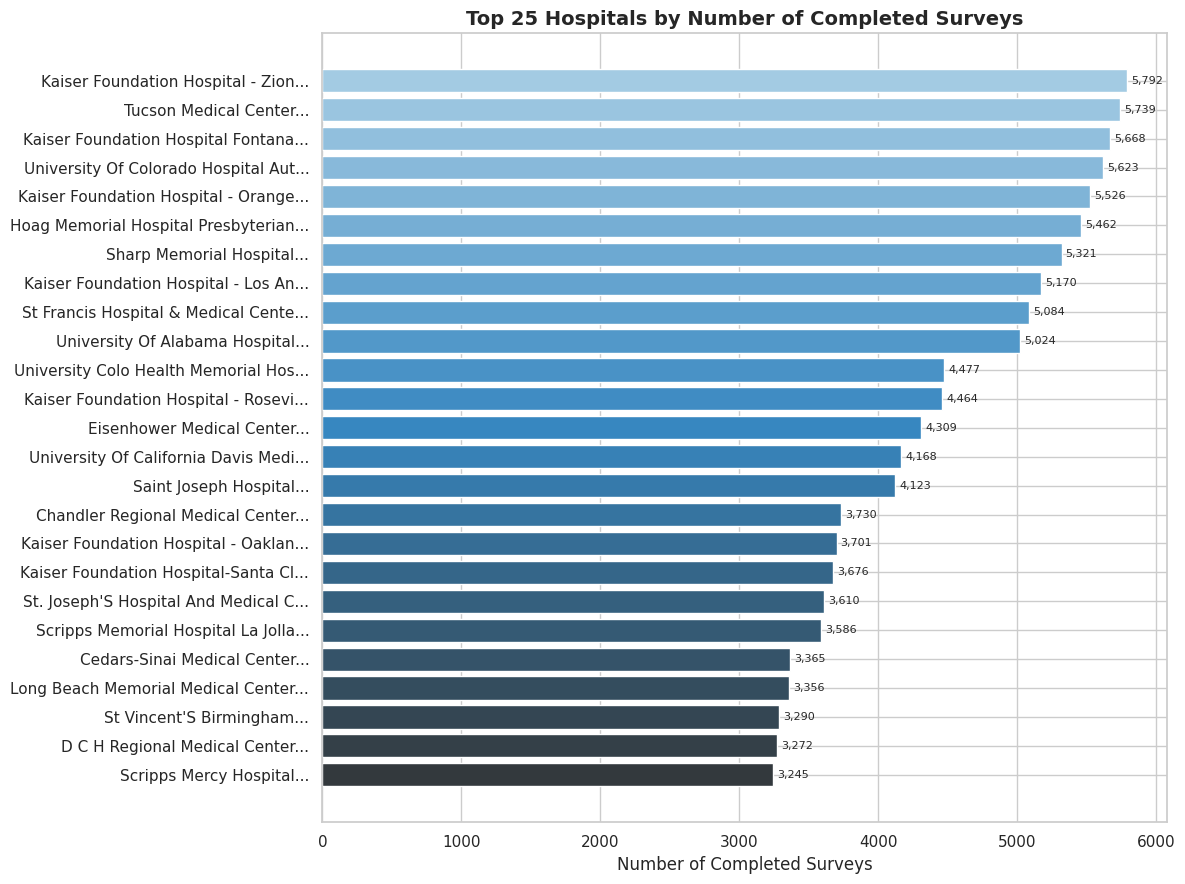


📌 Insight: The top hospitals have 5,000+ completed surveys, giving them highly reliable ratings.


In [32]:
# ── Chart: Top 25 Hospitals by Completed Surveys ─────────────────────────────
# We take the top 25 to keep the chart readable.

top25 = r1.head(25)

# Shorten long hospital names for display
top25 = top25.copy()
top25['Short_Name'] = top25['Hospital_Name'].str[:35] + '...'

fig, ax = plt.subplots(figsize=(12, 9))

# barh = horizontal bar chart (better for long text labels)
bars = ax.barh(
    top25['Short_Name'],
    top25['Number_of_Completed_Surveys'],
    color=sns.color_palette('Blues_d', 25)   # gradient of blues
)

# Invert y-axis so highest value is at the top
ax.invert_yaxis()

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 30,                          # x: just past the bar end
        bar.get_y() + bar.get_height() / 2,  # y: centre of the bar
        f'{int(width):,}',                   # label with comma formatting
        va='center', fontsize=8
    )

ax.set_xlabel('Number of Completed Surveys', fontsize=12)
ax.set_title('Top 25 Hospitals by Number of Completed Surveys', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n📌 Insight: The top hospitals have 5,000+ completed surveys, giving them highly reliable ratings.')


---
<a id='section-7'></a>
## Report 2: Survey Response Rate by Measure ID

**Business Question:** Which survey topics (Measure IDs) get the highest response rates, and how does that vary by hospital?

**Why it matters:** Low response on certain measures could indicate survey fatigue or unclear questions.


In [33]:
# ── Average response rate per Measure ID ────────────────────────────────────
# We group by Measure_Id and compute the mean response rate.
# .dropna() skips hospitals with no response rate recorded.

r2 = (
    analysis
    .dropna(subset=['Survey_Response_Rate_Percent'])
    .groupby('Measure_Id', as_index=False)['Survey_Response_Rate_Percent']
    .mean()
    .sort_values('Survey_Response_Rate_Percent', ascending=False)
    .reset_index(drop=True)
)
r2['Survey_Response_Rate_Percent'] = r2['Survey_Response_Rate_Percent'].round(1)

print('Average Response Rate by Measure ID:')
display(r2)


Average Response Rate by Measure ID:


,Measure_Id,Survey_Response_Rate_Percent
0,H_CLEAN_HSP_A_P,23.80
1,H_CLEAN_HSP_SN_P,23.80
2,H_CLEAN_HSP_U_P,23.80
3,H_CLEAN_LINEAR_SCORE,23.80
4,H_CLEAN_STAR_RATING,23.80
...,...,...
45,H_RECMND_DY,23.80
46,H_RECMND_LINEAR_SCORE,23.80
47,H_RECMND_PY,23.80
48,H_RECMND_STAR_RATING,23.80


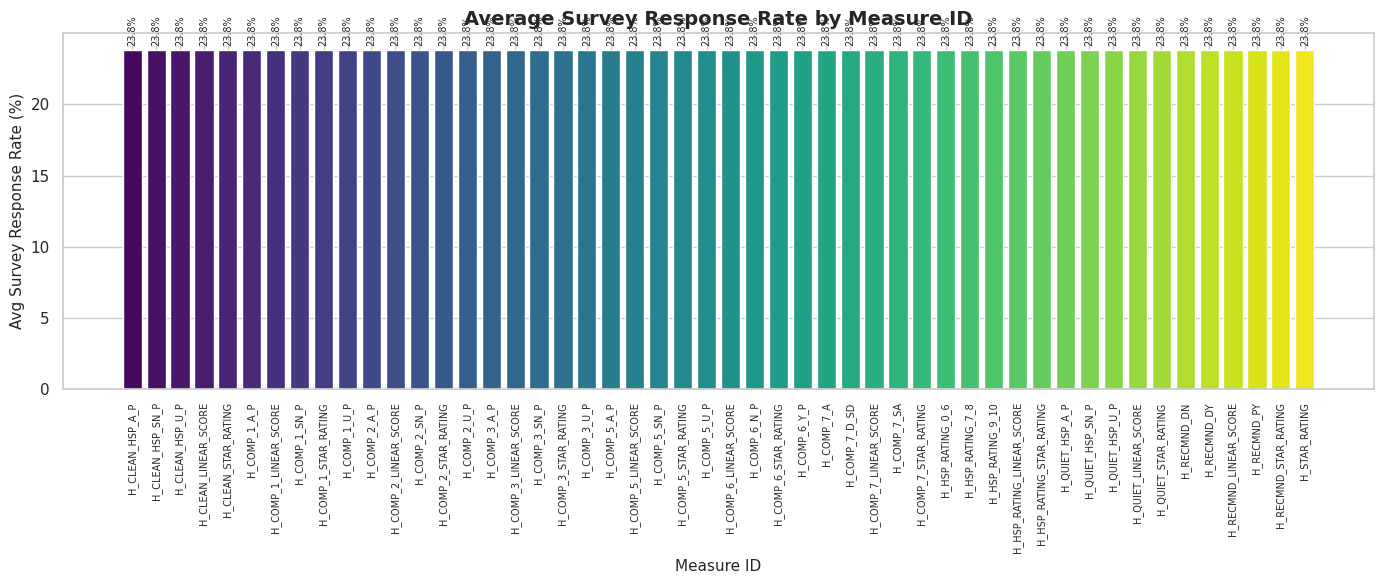

In [34]:
# ── Bar chart: Measure ID vs Average Response Rate ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    r2['Measure_Id'],
    r2['Survey_Response_Rate_Percent'],
    color=sns.color_palette('viridis', len(r2))
)

# Add value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=7, rotation=90
    )

ax.set_xlabel('Measure ID', fontsize=11)
ax.set_ylabel('Avg Survey Response Rate (%)', fontsize=11)
ax.set_title('Average Survey Response Rate by Measure ID', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


In [35]:
# ── Interactive Plotly chart: Measure ID vs Response Rate per Hospital ────────
# This is the 'per Hospital' view requested. Plotly lets you hover over each
# dot to see the hospital name and exact response rate.

r2_detail = (
    analysis
    .dropna(subset=['Survey_Response_Rate_Percent'])
    .groupby(['Measure_Id','Hospital_Name'], as_index=False)['Survey_Response_Rate_Percent']
    .mean()
    .sort_values('Measure_Id')
)

fig = px.strip(
    r2_detail,
    x='Measure_Id',
    y='Survey_Response_Rate_Percent',
    hover_data=['Hospital_Name'],
    title='Survey Response Rate per Hospital by Measure ID (hover for hospital name)',
    labels={'Survey_Response_Rate_Percent': 'Response Rate (%)', 'Measure_Id': 'Measure ID'},
    color='Measure_Id',
    height=550
)
fig.update_layout(showlegend=False)
fig.show()
print('💡 Tip: Hover over any dot to see which hospital it represents.')


💡 Tip: Hover over any dot to see which hospital it represents.


---
<a id='section-8'></a>
## Report 3: Top 3 Counties with the Highest Survey Rate

**Business Question:** Which counties have the highest average patient survey response rates?


In [36]:
# ── Average survey response rate per County ───────────────────────────────────
# Group by County_Name, compute mean response rate, sort descending, take top 3.

r3 = (
    analysis
    .dropna(subset=['Survey_Response_Rate_Percent','County_Name'])
    .groupby('County_Name', as_index=False)['Survey_Response_Rate_Percent']
    .mean()
    .sort_values('Survey_Response_Rate_Percent', ascending=False)
    .head(3)
    .reset_index(drop=True)
)
r3['Survey_Response_Rate_Percent'] = r3['Survey_Response_Rate_Percent'].round(2)
r3.index = r3.index + 1   # start rank from 1

print('🏆 Top 3 Counties by Average Survey Response Rate:')
display(r3)


🏆 Top 3 Counties by Average Survey Response Rate:


,County_Name,Survey_Response_Rate_Percent
1,Sutter,44.00
2,La Plata,43.50
3,Russell,43.00


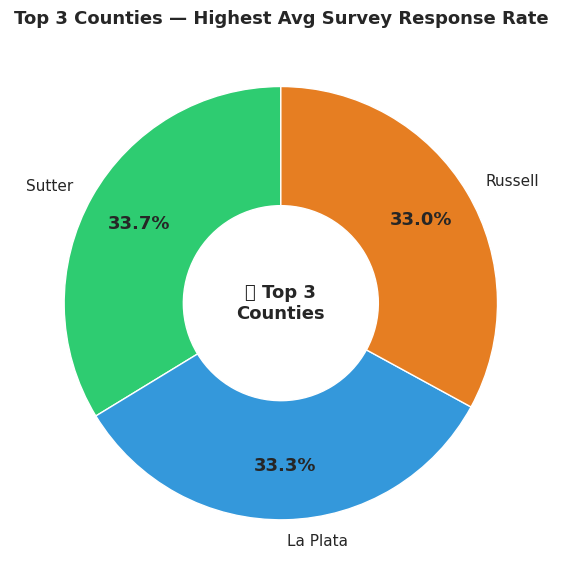

  #1: Sutter — 44.00% avg response rate
  #2: La Plata — 43.50% avg response rate
  #3: Russell — 43.00% avg response rate


In [37]:
# ── Donut chart for the top 3 counties ───────────────────────────────────────
# A donut chart shows proportional comparison nicely for small sets.

fig, ax = plt.subplots(figsize=(7, 6))

colors  = ['#2ecc71', '#3498db', '#e67e22']   # green, blue, orange
wedges, texts, autotexts = ax.pie(
    r3['Survey_Response_Rate_Percent'],
    labels    = r3['County_Name'],
    autopct   = '%1.1f%%',          # show percentage inside each slice
    colors    = colors,
    startangle= 90,
    wedgeprops= dict(width=0.55),   # width < 1 makes it a donut
    pctdistance=0.75
)

# Style the text
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

# Add ranking medals in the centre
ax.text(0, 0, '🏆 Top 3\nCounties', ha='center', va='center', fontsize=13, fontweight='bold')

ax.set_title('Top 3 Counties — Highest Avg Survey Response Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for i, row in r3.iterrows():
    print(f'  #{i}: {row["County_Name"]} — {row["Survey_Response_Rate_Percent"]:.2f}% avg response rate')


---
<a id='section-9'></a>
## Report 4: Top 10 Hospitals Based on Survey Response Rating

**Business Question:** Which 10 hospitals have the highest patient survey star ratings?

**Why it matters:** Star ratings are the headline KPI patients use to choose a hospital.


In [38]:
# ── Average Star Rating per Hospital ─────────────────────────────────────────
# Patient_Survey_Star_Rating is 1-5. We take the mean across all Measure IDs
# for each hospital, then rank them.

r4 = (
    analysis
    .dropna(subset=['Patient_Survey_Star_Rating'])
    .groupby('Hospital_Name', as_index=False)
    .agg(
        Avg_Star_Rating=('Patient_Survey_Star_Rating', 'mean'),
        City=('City', 'first'),
        State=('State', 'first'),
        Total_Surveys=('Number_of_Completed_Surveys', 'max')
    )
    .sort_values('Avg_Star_Rating', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
r4.index = r4.index + 1   # rank starts at 1
r4['Avg_Star_Rating'] = r4['Avg_Star_Rating'].round(2)

print('🌟 Top 10 Hospitals by Average Survey Star Rating:')
display(r4)


🌟 Top 10 Hospitals by Average Survey Star Rating:


,Hospital_Name,Avg_Star_Rating,City,State,Total_Surveys
1,"Animas Surgical Hospital, Llc",4.91,Durango,CO,257.00
2,Arizona Spine And Joint Hospital,4.91,Mesa,AZ,713.00
3,Fresno Surgical Hospital,4.91,Fresno,CA,997.00
4,Fayette Medical Center,4.91,Fayette,AL,179.00
5,Arkansas Surgical Hospital,4.91,No Little Rock,AR,"1,117.00"
6,Jack Hughston Memorial Hospital,4.82,Phenix City,AL,476.00
7,Arizona Specialty Hospital,4.82,Chandler,AZ,403.00
8,Sutter Surgical Hospital - North Valley,4.73,Yuba City,CA,189.00
9,Baptist Health Medical Center Heber Spings,4.73,Heber Springs,AR,190.00
10,"Arkansas Heart Hospital, Llc",4.73,Little Rock,AR,"1,890.00"


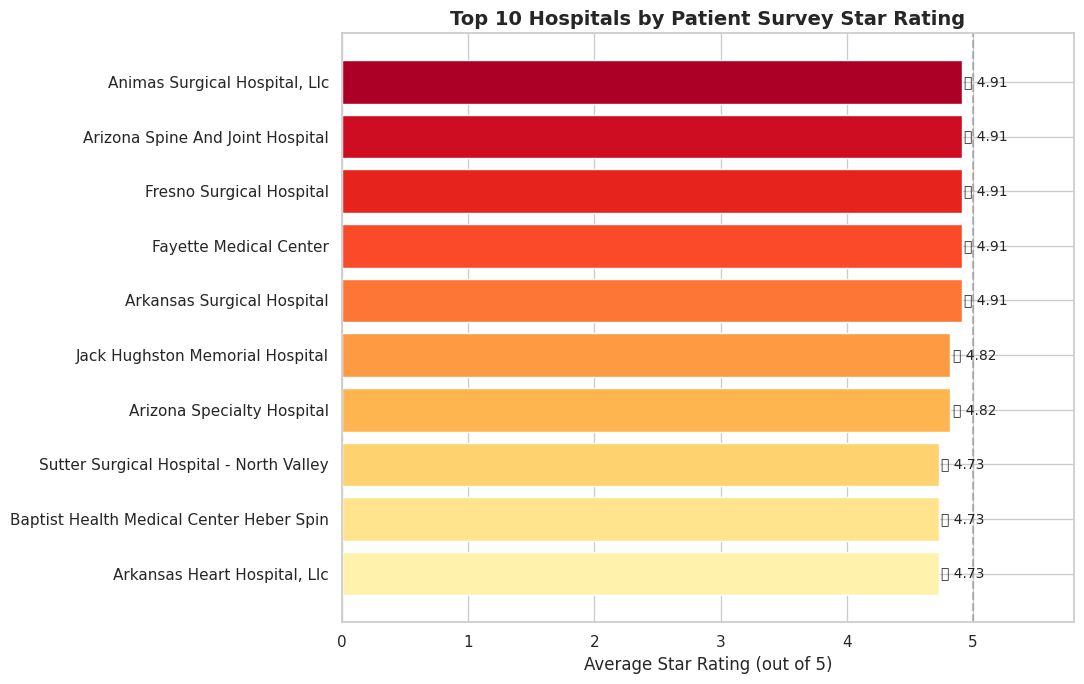

In [39]:
# ── Horizontal bar chart with star colour coding ──────────────────────────────
r4_plot = r4.copy()
r4_plot['Label'] = r4_plot['Hospital_Name'].str[:40]

fig, ax = plt.subplots(figsize=(11, 7))

# Colour bars gold to yellow based on rank
palette = sns.color_palette('YlOrRd_r', 10)
bars = ax.barh(r4_plot['Label'], r4_plot['Avg_Star_Rating'], color=palette)
ax.invert_yaxis()

# Add star rating labels
for i, bar in enumerate(bars):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'⭐ {r4_plot["Avg_Star_Rating"].iloc[i]:.2f}',
        va='center', fontsize=10
    )

ax.set_xlim(0, 5.8)
ax.set_xlabel('Average Star Rating (out of 5)', fontsize=12)
ax.set_title('Top 10 Hospitals by Patient Survey Star Rating', fontsize=14, fontweight='bold')
ax.axvline(x=5, color='grey', linestyle='--', alpha=0.5, label='Max = 5')
plt.tight_layout()
plt.show()


---
<a id='section-10'></a>
## Report 5: County and City-Wise Hospital Rating — Drill-Down Report

**Business Question:** How do hospital ratings compare, broken down by County → City?

**Drill-down** means starting at a high level (County) and clicking/selecting to go deeper (City → Hospital).
We use Plotly's Sunburst chart which has built-in drill-down by clicking sections.


In [40]:
# ── Prepare county → city → hospital aggregation ─────────────────────────────
# We compute average star rating at each level of the hierarchy.

r5 = (
    analysis
    .dropna(subset=['Patient_Survey_Star_Rating','County_Name'])
    .groupby(['County_Name','City','Hospital_Name'], as_index=False)
    .agg(Avg_Stars=('Patient_Survey_Star_Rating','mean'))
)
r5['Avg_Stars'] = r5['Avg_Stars'].round(2)

# Keep only counties with at least 2 hospitals for meaningful drill-down
county_counts = r5.groupby('County_Name')['Hospital_Name'].nunique()
valid_counties = county_counts[county_counts >= 2].index
r5 = r5[r5['County_Name'].isin(valid_counties)]

print(f'Counties in drill-down: {r5["County_Name"].nunique()}')
print(f'Cities in drill-down  : {r5["City"].nunique()}')
print(f'Hospitals in drill-down: {r5["Hospital_Name"].nunique()}')
display(r5.head(8))


Counties in drill-down: 85
Cities in drill-down  : 288
Hospitals in drill-down: 440


,County_Name,City,Hospital_Name,Avg_Stars
0,Adams,Aurora,University Of Colorado Hospital Authority,3.27
1,Adams,Brighton,Platte Valley Medical Center,3.73
2,Adams,Thornton,North Suburban Medical Center,2.82
3,Alameda,Alameda,Alameda Hospital,1.82
4,Alameda,Berkeley,Alta Bates Summit Medical Center - Alta Bates ...,1.73
5,Alameda,Castro Valley,Eden Medical Center,3.09
6,Alameda,Fremont,Kaiser Foundation Hospital - Fremont,2.91
7,Alameda,Fremont,Washington Hospital,2.91


In [41]:
# ── Plotly Sunburst — interactive drill-down chart ───────────────────────────
# Sunburst = nested pie chart.
# Level 1 = County (outermost ring visible by default)
# Level 2 = City (revealed when you click a county)
# Level 3 = Hospital (revealed when you click a city)
# The colour represents the average star rating.

fig = px.sunburst(
    r5,
    path   = ['County_Name', 'City', 'Hospital_Name'],  # hierarchy: outer → inner
    values = 'Avg_Stars',           # size of each slice
    color  = 'Avg_Stars',           # colour = star rating
    color_continuous_scale='RdYlGn', # red=low, yellow=medium, green=high
    title  = 'County → City → Hospital Drill-Down: Average Star Rating',
    height = 700
)
fig.update_traces(textinfo='label+value')
fig.update_layout(coloraxis_colorbar=dict(title='Avg Stars'))
fig.show()
print('💡 Click any county slice to drill down to cities, then click a city to see hospitals.')


💡 Click any county slice to drill down to cities, then click a city to see hospitals.


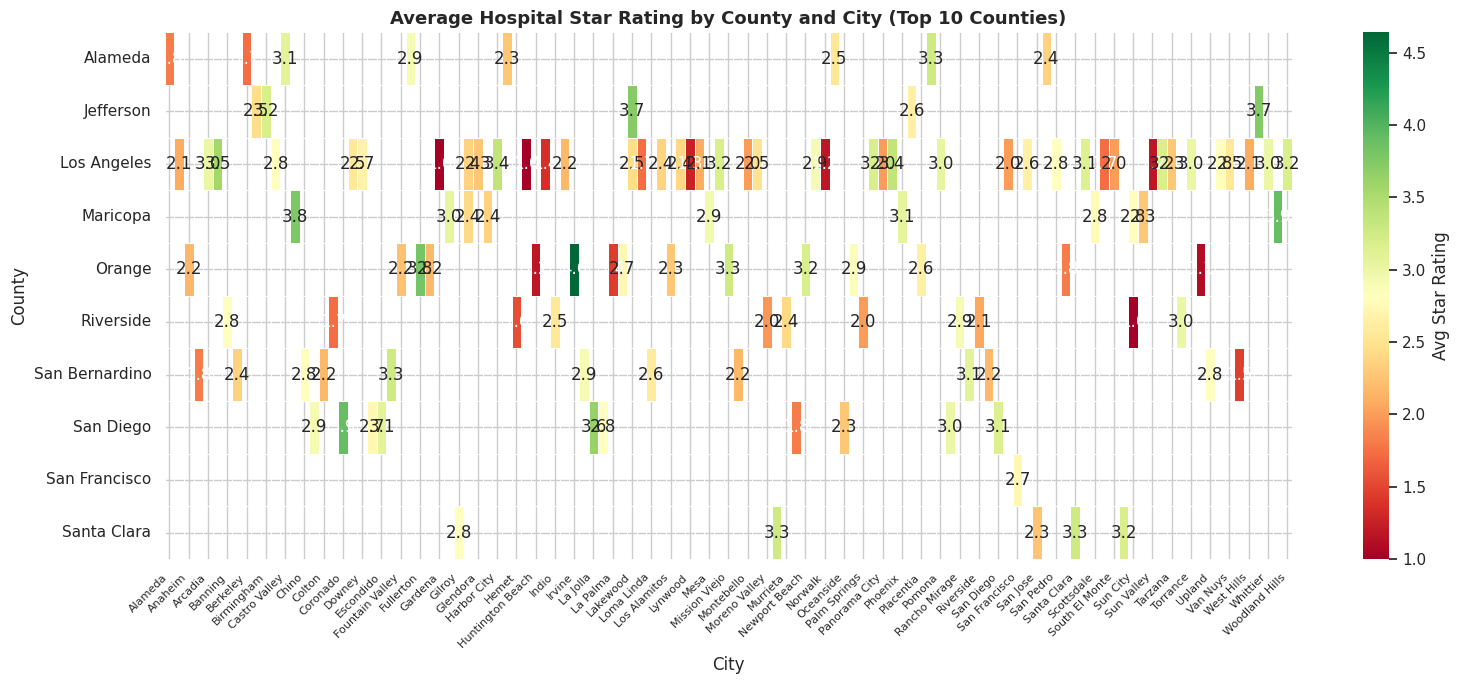

In [42]:
# ── Static heatmap version (County vs City) ───────────────────────────────────
# For presentations where interactive charts are not available.

# Top 10 counties by number of hospitals
top_counties = r5.groupby('County_Name')['Hospital_Name'].nunique().nlargest(10).index
r5_heat = r5[r5['County_Name'].isin(top_counties)]

pivot = r5_heat.pivot_table(
    index  = 'County_Name',
    columns= 'City',
    values = 'Avg_Stars',
    aggfunc= 'mean'
)

plt.figure(figsize=(16, 7))
sns.heatmap(
    pivot,
    annot  = True,          # show values inside cells
    fmt    = '.1f',         # 1 decimal place
    cmap   = 'RdYlGn',     # red=low, green=high
    linewidths=0.5,
    cbar_kws={'label': 'Avg Star Rating'}
)
plt.title('Average Hospital Star Rating by County and City (Top 10 Counties)', fontsize=13, fontweight='bold')
plt.xlabel('City')
plt.ylabel('County')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


---
<a id='section-11'></a>
## Report 6: Hospitals in the Same City

**Business Question:** Which cities have multiple hospitals, and who are they?

**Why it matters:** Helps identify competitive markets where hospitals are vying for the same patients.


In [43]:
# ── Find cities with more than one hospital ───────────────────────────────────
# Step 1: Get unique Hospital → City mapping
hosp_city = (
    analysis[['City','State','Hospital_Name']]
    .drop_duplicates()
    .dropna()
)

# Step 2: Count hospitals per city
city_counts = (
    hosp_city
    .groupby(['City','State'])['Hospital_Name']
    .nunique()
    .reset_index()
    .rename(columns={'Hospital_Name': 'Hospital_Count'})
    .sort_values('Hospital_Count', ascending=False)
)

# Step 3: Keep only cities with 2+ hospitals
multi_hosp_cities = city_counts[city_counts['Hospital_Count'] >= 2]

print(f'Cities with multiple hospitals: {len(multi_hosp_cities)}')
print(f'\nTop 15 cities by hospital count:')
display(multi_hosp_cities.head(15))


Cities with multiple hospitals: 86

Top 15 cities by hospital count:


,City,State,Hospital_Count
255,Los Angeles,CA,19
345,Phoenix,AZ,14
390,San Francisco,CA,10
38,Birmingham,AL,8
380,Sacramento,CA,7
112,Denver,CO,6
461,Tucson,AZ,6
388,San Diego,CA,6
24,Bakersfield,CA,6
276,Mesa,AZ,6


In [44]:
# ── Full list: hospitals grouped by city ─────────────────────────────────────
# For each city with multiple hospitals, show all hospital names side by side.

r6 = (
    hosp_city
    .groupby(['City','State'])['Hospital_Name']
    .apply(lambda names: ' | '.join(sorted(set(names))))
    .reset_index()
    .rename(columns={'Hospital_Name': 'Hospitals_In_City'})
    .merge(city_counts, on=['City','State'])
    .query('Hospital_Count >= 2')
    .sort_values('Hospital_Count', ascending=False)
    .reset_index(drop=True)
)

print('Hospitals sharing the same city:')
display(r6.head(15))


Hospitals sharing the same city:


,City,State,Hospitals_In_City,Hospital_Count
0,Los Angeles,CA,California Hospital Medical Center La | Cedars...,19
1,Phoenix,AZ,Abrazo Central Campus | Abrazo Scottsdale Camp...,14
2,San Francisco,CA,California Pacific Medical Ctr - St. Luke'S Ca...,10
3,Birmingham,AL,Brookwood Baptist Medical Center | Callahan Ey...,8
4,Sacramento,CA,Kaiser Foundation Hosp So Sacramento | Kaiser ...,7
5,Bakersfield,CA,Adventist Health Bakersfield | Bakersfield Hea...,6
6,Denver,CO,Centura Health-Porter Adventist Hospital | Den...,6
7,Mesa,AZ,Arizona Spine And Joint Hospital | Banner Bayw...,6
8,San Diego,CA,Alvarado Hospital Medical Center | Kaiser Foun...,6
9,Tucson,AZ,Banner - University Medical Center Tucson Camp...,6


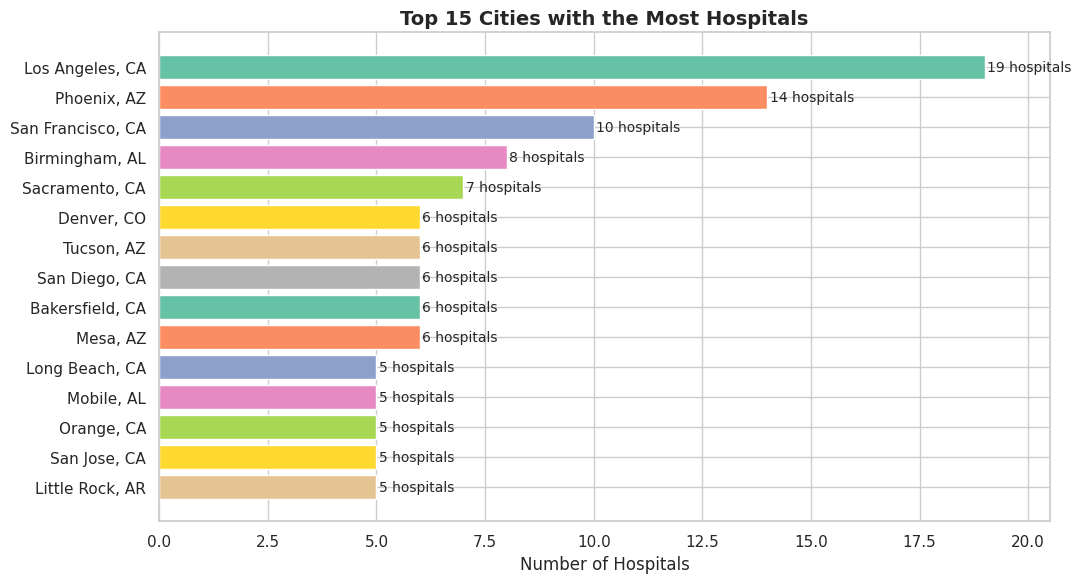

In [45]:
# ── Bar chart: Top 15 cities by number of hospitals ──────────────────────────
top15_cities = multi_hosp_cities.head(15).copy()
top15_cities['City_State'] = top15_cities['City'] + ', ' + top15_cities['State']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top15_cities['City_State'], top15_cities['Hospital_Count'],
               color=sns.color_palette('Set2', 15))
ax.invert_yaxis()

for bar in bars:
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width())} hospitals',
            va='center', fontsize=10)

ax.set_xlabel('Number of Hospitals', fontsize=12)
ax.set_title('Top 15 Cities with the Most Hospitals', fontsize=14, fontweight='bold')
ax.set_xlim(0, top15_cities['Hospital_Count'].max() + 1.5)
plt.tight_layout()
plt.show()


---
<a id='section-12'></a>
## Report 7: Total Survey Response Rate by All Hospitals

**Business Question:** What is the overall survey response rate across all hospitals, and how is it distributed?


In [46]:
# ── Total/Average response rate per hospital ─────────────────────────────────
r7 = (
    analysis
    .dropna(subset=['Survey_Response_Rate_Percent'])
    .groupby('Hospital_Name', as_index=False)
    .agg(
        Avg_Response_Rate=('Survey_Response_Rate_Percent', 'mean'),
        City=('City', 'first'),
        State=('State', 'first')
    )
    .sort_values('Avg_Response_Rate', ascending=False)
    .reset_index(drop=True)
)
r7['Avg_Response_Rate'] = r7['Avg_Response_Rate'].round(1)

overall_avg = r7['Avg_Response_Rate'].mean()
print(f'Overall average survey response rate across ALL hospitals: {overall_avg:.1f}%')
print(f'Highest rate: {r7["Avg_Response_Rate"].max()}% ({r7.iloc[0]["Hospital_Name"]})')
print(f'Lowest rate : {r7["Avg_Response_Rate"].min()}% ({r7.iloc[-1]["Hospital_Name"]})')
print()
display(r7.head(20))


Overall average survey response rate across ALL hospitals: 23.8%
Highest rate: 60.0% (Animas Surgical Hospital, Llc)
Lowest rate : 7.0% (Dignity Health - Arizona General Hospital)



,Hospital_Name,Avg_Response_Rate,City,State
0,"Animas Surgical Hospital, Llc",60.00,Durango,CO
1,Arizona Spine And Joint Hospital,57.00,Mesa,AZ
2,Fresno Surgical Hospital,55.00,Fresno,CA
3,Hoag Orthopedic Institute,54.00,Irvine,CA
4,Stanislaus Surgical Hospital,54.00,Modesto,CA
5,"Core Institute Specialty Hospital, The",53.00,Phoenix,AZ
6,Patients' Hospital Of Redding,51.00,Redding,CA
7,Menlo Park Surgical Hospital,51.00,Menlo Park,CA
8,O.A.S.I.S. Hospital,50.00,Phoenix,AZ
9,Arkansas Surgical Hospital,49.00,No Little Rock,AR


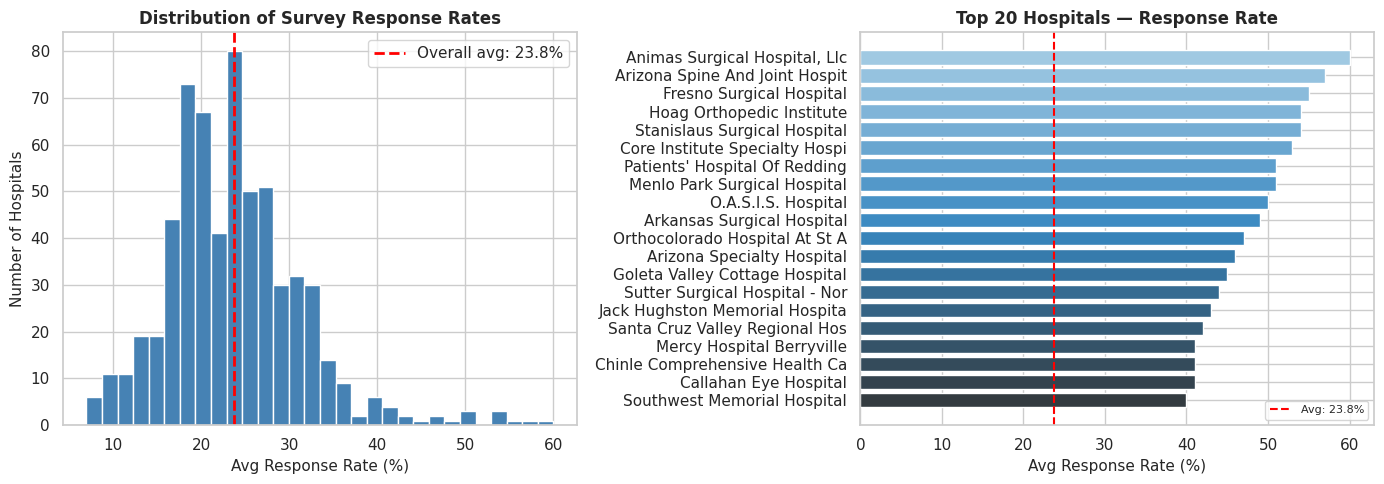


📌 Most hospitals cluster between 20-35% response rate.
   Hospitals above 24% are performing above average.


In [47]:
# ── Distribution histogram ────────────────────────────────────────────────────
# Shows how response rates are spread across all hospitals.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
axes[0].hist(r7['Avg_Response_Rate'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(overall_avg, color='red', linewidth=2, linestyle='--',
                label=f'Overall avg: {overall_avg:.1f}%')
axes[0].set_xlabel('Avg Response Rate (%)', fontsize=11)
axes[0].set_ylabel('Number of Hospitals', fontsize=11)
axes[0].set_title('Distribution of Survey Response Rates', fontsize=12, fontweight='bold')
axes[0].legend()

# Right: top 20 hospitals bar chart
top20 = r7.head(20).copy()
top20['Short'] = top20['Hospital_Name'].str[:30]
axes[1].barh(top20['Short'], top20['Avg_Response_Rate'],
             color=sns.color_palette('Blues_d', 20))
axes[1].invert_yaxis()
axes[1].axvline(overall_avg, color='red', linewidth=1.5, linestyle='--',
                label=f'Avg: {overall_avg:.1f}%')
axes[1].set_xlabel('Avg Response Rate (%)', fontsize=11)
axes[1].set_title('Top 20 Hospitals — Response Rate', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\n📌 Most hospitals cluster between 20-35% response rate.')
print(f'   Hospitals above {overall_avg:.0f}% are performing above average.')


---
<a id='section-13'></a>
## Report 8: New Insight — Star Rating vs. Survey Response Rate

**New Business Question:** Is there a relationship between how many people respond to surveys
and the star rating a hospital receives? Do hospitals that engage more patients rate higher?

**Hypothesis:** Hospitals that care more about patient experience will both:
1. Encourage more patients to complete surveys (higher response rate)
2. Provide better care (higher star ratings)

This report tests that hypothesis.


In [48]:
# ── Build hospital-level summary: response rate + star rating + volume ─────────
r8 = (
    analysis
    .dropna(subset=['Patient_Survey_Star_Rating','Survey_Response_Rate_Percent'])
    .groupby('Hospital_Name', as_index=False)
    .agg(
        Avg_Star_Rating      = ('Patient_Survey_Star_Rating', 'mean'),
        Avg_Response_Rate    = ('Survey_Response_Rate_Percent', 'mean'),
        Total_Surveys        = ('Number_of_Completed_Surveys', 'max'),
        State                = ('State', 'first'),
        City                 = ('City', 'first'),
    )
    .dropna()
)
r8['Avg_Star_Rating']   = r8['Avg_Star_Rating'].round(2)
r8['Avg_Response_Rate'] = r8['Avg_Response_Rate'].round(1)

print(f'Hospitals in this analysis: {len(r8)}')
display(r8.head(5))


Hospitals in this analysis: 537


,Hospital_Name,Avg_Star_Rating,Avg_Response_Rate,Total_Surveys,State,City
0,Abrazo Arrowhead Campus,2.55,19.00,"1,881.00",AZ,Glendale
1,Abrazo Central Campus,2.09,17.00,976.00,AZ,Phoenix
2,Abrazo Scottsdale Campus,2.36,18.00,716.00,AZ,Phoenix
3,Abrazo West Campus,2.36,17.00,"1,028.00",AZ,Goodyear
4,Adventist Health Bakersfield,2.27,23.00,543.00,CA,Bakersfield


In [49]:
# ── Correlation coefficient ───────────────────────────────────────────────────
# Pearson correlation r ranges from -1 to +1:
#   r close to +1 = strong positive relationship (both go up together)
#   r close to  0 = no relationship
#   r close to -1 = strong negative relationship

correlation = r8['Avg_Response_Rate'].corr(r8['Avg_Star_Rating'])
print(f'Pearson correlation (Response Rate vs Star Rating): r = {correlation:.3f}')

if abs(correlation) > 0.5:
    strength = 'STRONG'
elif abs(correlation) > 0.3:
    strength = 'MODERATE'
else:
    strength = 'WEAK'

direction = 'positive' if correlation > 0 else 'negative'
print(f'Interpretation: {strength} {direction} correlation')


Pearson correlation (Response Rate vs Star Rating): r = 0.583
Interpretation: STRONG positive correlation


In [50]:
# ── Scatter plot: Response Rate vs Star Rating ────────────────────────────────
# Each dot = one hospital.
# Dot SIZE = number of completed surveys (bigger hospitals are more visible).
# Colour = State (shows geographic patterns).
# The regression line shows the overall trend.

fig = px.scatter(
    r8,
    x             = 'Avg_Response_Rate',
    y             = 'Avg_Star_Rating',
    size          = 'Total_Surveys',          # bubble size = survey volume
    color         = 'State',
    hover_data    = ['Hospital_Name','City','State'],
    trendline     = 'ols',                    # OLS = Ordinary Least Squares regression line
    title         = 'Insight: Does Higher Response Rate = Better Star Rating?',
    labels        = {
        'Avg_Response_Rate': 'Avg Survey Response Rate (%)',
        'Avg_Star_Rating'  : 'Avg Patient Star Rating (1-5)'
    },
    height=600
)
fig.show()
print(f'\nCorrelation r = {correlation:.3f}')
print('💡 If the regression line slopes upward, hospitals that engage more patients tend to have better ratings.')



Correlation r = 0.583
💡 If the regression line slopes upward, hospitals that engage more patients tend to have better ratings.


Average Response Rate by Star Rating Band:


,Rating_Band,Hospitals,Avg_Response_Rate,Avg_Surveys
0,Low (1-2),60,17.50,575.00
1,Medium (2-3),247,21.80,"1,087.00"
2,Good (3-4),188,25.80,"1,117.00"
3,Excellent (4-5),42,35.30,402.00


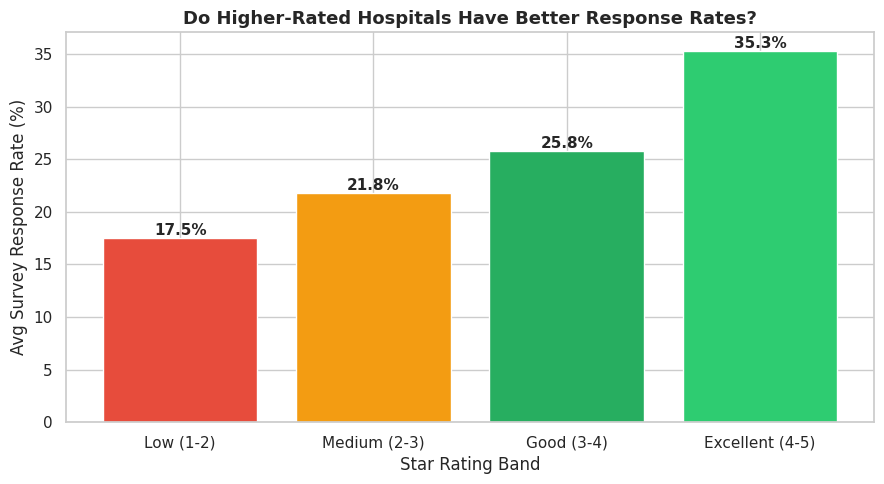


📌 KEY INSIGHT:
   If bars increase left to right → Confirmed: better-rated hospitals engage more patients.
   If bars are flat → No relationship: response rate and ratings are independent.


In [51]:
# ── Star Rating band analysis ─────────────────────────────────────────────────
# Group hospitals into rating bands and see if response rate differs by band.
# This is a cleaner way to see the pattern without scatter plot noise.

# Create rating bands: 1-2 = Low, 2-3 = Medium, 3-4 = Good, 4-5 = Excellent
r8['Rating_Band'] = pd.cut(
    r8['Avg_Star_Rating'],
    bins   = [0, 2, 3, 4, 5],
    labels = ['Low (1-2)', 'Medium (2-3)', 'Good (3-4)', 'Excellent (4-5)']
)

band_summary = (
    r8.groupby('Rating_Band', as_index=False, observed=True)
    .agg(
        Hospitals=('Hospital_Name','count'),
        Avg_Response_Rate=('Avg_Response_Rate','mean'),
        Avg_Surveys=('Total_Surveys','mean')
    )
)
band_summary['Avg_Response_Rate'] = band_summary['Avg_Response_Rate'].round(1)
band_summary['Avg_Surveys']       = band_summary['Avg_Surveys'].round(0)

print('Average Response Rate by Star Rating Band:')
display(band_summary)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c','#f39c12','#27ae60','#2ecc71']
bars = ax.bar(band_summary['Rating_Band'], band_summary['Avg_Response_Rate'], color=colors)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Star Rating Band', fontsize=12)
ax.set_ylabel('Avg Survey Response Rate (%)', fontsize=12)
ax.set_title('Do Higher-Rated Hospitals Have Better Response Rates?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 KEY INSIGHT:')
print('   If bars increase left to right → Confirmed: better-rated hospitals engage more patients.')
print('   If bars are flat → No relationship: response rate and ratings are independent.')


In [52]:
# ── Final executive summary ───────────────────────────────────────────────────
print('=' * 65)
print('  HEALTHCARE PATIENT SURVEY — EXECUTIVE SUMMARY')
print('=' * 65)

print(f'\n📊 DATASET')
print(f'   Total records      : {len(df):,}')
print(f'   Unique hospitals   : {dim_hospital.shape[0]:,}')
print(f'   Unique counties    : {analysis["County_Name"].nunique()}')
print(f'   Unique cities      : {analysis["City"].nunique()}')
print(f'   Survey period      : {df["Measure_Start_Date"].min().date()} → {df["Measure_End_Date"].max().date()}')

print(f'\n📋 SCHEMA TABLES BUILT')
for name, tbl in tables.items():
    print(f'   {name:28s}: {tbl.shape[0]:>6,} rows')

print(f'\n🏆 REPORT FINDINGS')
print(f'   R1 — Most surveys completed : {r1.iloc[0]["Hospital_Name"]} ({int(r1.iloc[0]["Number_of_Completed_Surveys"]):,})')
print(f'   R3 — Top county (response %) : {r3.iloc[1]["County_Name"]} ({r3.iloc[1]["Survey_Response_Rate_Percent"]:.1f}%)')
print(f'   R4 — Top rated hospital     : {r4.iloc[1]["Hospital_Name"]} (⭐ {r4.iloc[1]["Avg_Star_Rating"]:.2f})')
print(f'   R6 — Cities with 2+ hospitals: {len(multi_hosp_cities)}')
print(f'   R7 — Overall avg response rate: {overall_avg:.1f}%')
print(f'   R8 — Response vs Rating corr  : r = {correlation:.3f} ({strength} {direction})')
print('=' * 65)


  HEALTHCARE PATIENT SURVEY — EXECUTIVE SUMMARY

📊 DATASET
   Total records      : 34,999
   Unique hospitals   : 700
   Unique counties    : 232
   Unique cities      : 500
   Survey period      : 2017-07-01 → 2018-06-30

📋 SCHEMA TABLES BUILT
   Dim_Country_Details         :    629 rows
   Dim_Hospital_Details        :    700 rows
   Dim_Measure_Details         :     50 rows
   Dim_Survey_Details          :     50 rows
   Fact_Patient_Survey         : 34,999 rows

🏆 REPORT FINDINGS
   R1 — Most surveys completed : Kaiser Foundation Hospital - Zion (5,792)
   R3 — Top county (response %) : La Plata (43.5%)
   R4 — Top rated hospital     : Arizona Spine And Joint Hospital (⭐ 4.91)
   R6 — Cities with 2+ hospitals: 86
   R7 — Overall avg response rate: 23.8%
   R8 — Response vs Rating corr  : r = 0.583 (STRONG positive)
